In [1]:
import numpy as np
import xarray as xr
import toml
import munch
from tqdm import tqdm
import torch
import datetime

import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.utils_mlflow import load_model_from_mlflow
from Fires._utilities.utils_inference import get_cmip6_inference

In [ ]:
config = munch.munchify(toml.load("/ceph/hpc/home/ciangottinid/ML4Fires/config/cmip6_inference.toml"))
searfire_ds_path = "/ceph/hpc/home/ciangottinid/ML4Fires_data/data_100km.zarr"
sea_poles_mask_path = "data/land_sea_poles_mask.nc"
seafire_ds = xr.open_zarr(searfire_ds_path)
sea_poles_mask = xr.open_dataset(sea_poles_mask_path)

In [3]:
import ipywidgets as widgets

scenario = widgets.Dropdown(
    options=[('SSP126', 'ssp126'), ('SSP245', 'ssp245'), ('SSP370', 'ssp370'),
             ('SSP585', 'ssp585')],
    value = 'ssp126',
    style={'description_width': '60px'}, 
    description='Scenario', disabled=False,
    layout=widgets.Layout(width='200px'))

climate_model = widgets.Dropdown(
    options=[('MPI-ESM1-2-HR', 'MPI-ESM1-2-HR'), ('CMCC-ESM2', 'CMCC-ESM2'), ('NorESM2-MM', 'NorESM2-MM'),
             ('CESM2', 'CESM2')],
    value = 'CMCC-ESM2',
    style={'description_width': '60px'}, 
    description='Model', disabled=False,
    layout=widgets.Layout(width='200px'))

year_range = widgets.IntRangeSlider(
    value=[2030, 2035],        # initial range
    min=2015,                 # min value
    max=2100,               # max value
    step=1,                # step size
    description='Year range:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px')
)

display(widgets.HBox([scenario, climate_model, year_range]))

In [4]:
assert scenario.value != None, "Please select a CMIP6 scenario in the previous cell before proceesind"

In [5]:
# run_name=input()
run_name="last"
registered_model = load_model_from_mlflow(run_name, provenance=True)
# registered_model

Data from MLFlow downloaded in: /jupyter-workspace/persistent-storage/ML4Fires/MLFLOW/last


2025/07/22 16:17:08 WARNING mlflow.pytorch: Stored model version '2.4.1+cu121' does not match installed PyTorch version '2.4.1+cu124'


In [6]:
predictions = get_cmip6_inference(
    seafire_ds=seafire_ds,
    run_name=run_name,
    scenario=scenario,
    climate_model=climate_model,
    year_range=year_range,
    infer_config=config,
    model=registered_model)


📘 Running inference for scenario: ssp126, years: 2030–2035
Loading the following CMIP6 data files from RUCIO:
  lai: ['/dcache/sling.si/projects/intertwin/abennasser/lai_Eday_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20641231.nc']
  tasmax: ['/dcache/sling.si/projects/intertwin/abennasser/tasmax_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc']
  hur: ['/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20290101-20301231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20310101-20321231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20330101-20341231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20350101-20361231.nc']
  tasmin: ['/dcache/sling.si/projects/intertwin/abennasser/tasmin_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc']
  pr: ['/dcache/sling.si/projects/intertwin/abennasser/pr_day_CMCC-ESM2_ssp126_r1i1p1f1_g

In [7]:
monthly_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'sum',
    style={'description_width': '150px'}, 
    description='Monthly aggregate', disabled=False,)

monthly_add_period = widgets.Dropdown(
    options=[('1 Month', '1M'), ('2 Months', '2M'), ('4 Months', '4M'),
             ('6 Month', '6M')],
    value = '1M',
    style={'description_width': '150px'}, 
    description='Monthly aggregate period', disabled=False,)

yearly_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'mean',
    style={'description_width': '150px'}, 
    description='Yearly aggregate', disabled=False,)

decadal_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'mean',
    style={'description_width': '150px'}, 
    description='Decadal aggregate', disabled=False,)

display(widgets.HBox([monthly_agg,
                      monthly_add_period]))
        
display(widgets.VBox([yearly_agg,
                      decadal_agg]))


['lai', 'lst_day', 'rel_hum', 'sst', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)
 Mean of data: (180, 360)
 Max: 11484.8203125 	 Min: 0.009999999776482582
 Lats Max: 1102.3299560546875 	 Lons Max: 618.2100219726562
 Mean of data: (180, 360)
 Max: 7516.240234375 	 Min: 0.0
 Lats Max: 458.739990234375 	 Lons Max: 238.72999572753906


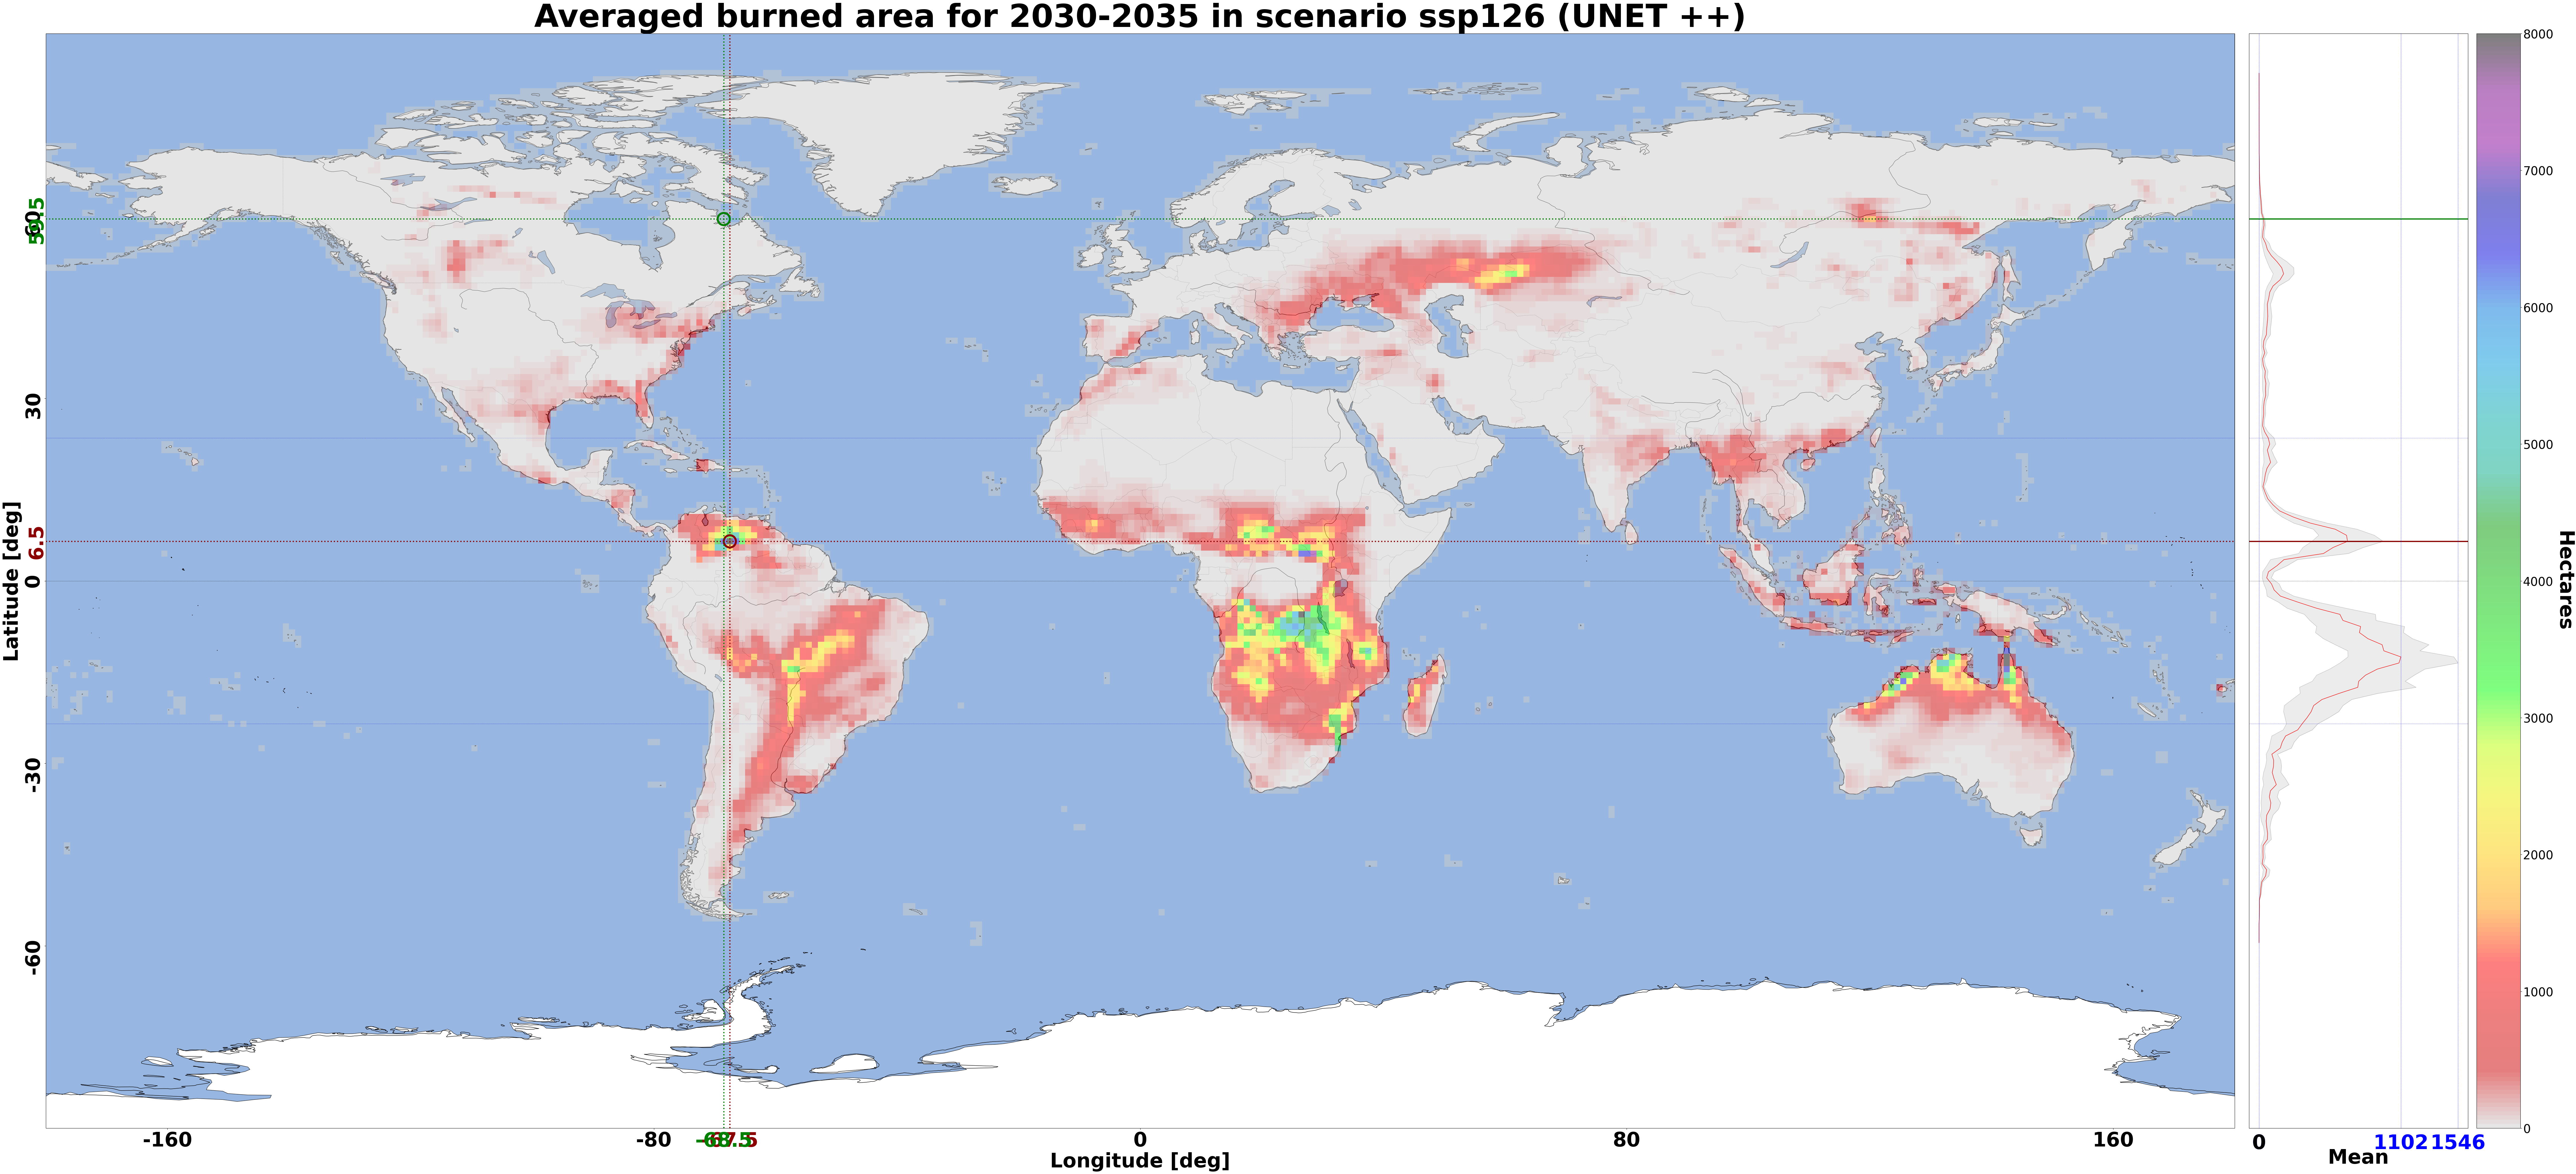

In [ ]:
from Fires._utilities.utils_inference import process_and_plot_cmip6infer, process_and_plot_data, load_input_data
input_data = load_input_data(searfire_ds_path, '2019', '2020') # Required by internal setting of variables in Fires._utilities.utils_inference

temporal_aggregate_scheme = {"monthly":[monthly_agg.value,monthly_add_period.value],
                             "yearly":yearly_agg.value,
                            "decadal":decadal_agg.value}
process_and_plot_cmip6infer(
	data=predictions["global_burned_areas"],
	temporal_aggregate_scheme=temporal_aggregate_scheme,
	label=f'Averaged burned area for {year_range.value[0]}-{year_range.value[1]} in scenario {scenario.value}',
	lats=seafire_ds.latitude.values,
	lons=seafire_ds.longitude.values,
    scale_min=0,
    scale_max=8000,
	model_name="Unet ++",
	sea_poles_mask=sea_poles_mask["basis_regions"].sel(cl=0)
)